# Synth. Obs.: Analytic Sphere

## Setup

Import the required functionalty.

In [1]:
import magritte.core     as magritte   # Core functionality
import magritte.plot     as plot       # Plotting
import magritte.tools    as tools      # Save fits
import os
import numpy as np
from astropy import units              # Unit conversions

Define a working directory (you will have to change this). We assume here that the scripts of the [this example](../0_creating_models/0_create_analytic_disk.ipynb) have already been executed and go back to that working directory.

In [2]:
wdir = "/home/yasho379/magritte_rebuilt/tgs"

Define file names.

In [3]:
#model_file = os.path.join(wdir, 'model_analytic_spherical_nh3.hdf5')   # Analytic spiral Magritte model
model_file = os.path.join(wdir, 'model_analytic_sphere_hcn.hdf5')   # Resulting Magritte model

Load the Magritte model.

In [4]:
model = magritte.Model(model_file)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /home/yasho379/magritte_rebuilt/tgs/model_analytic_sphere_hcn.hdf5
-------------------------------------------
Reading parameters...
Reading points...
Reading rays...
Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 0
read sym HCN
nlev = 25
nrad = 45
Reading collisionPartner...
Reading quadrature...


Reading radiation...
Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 16965
  nrays      = 2
  nboundary  = 3000
  nfreqs     = 2295
  nspecs     = 3
  nlspecs    = 1
  nlines     = 45
  nquads     = 51
-------------------------------------------
                                           


## Model the medium

Initialize the model by setting up a spectral discretisation, computing the inverse line widths and initializing the level populations with their LTE values.

In [5]:
model.compute_spectral_discretisation ()
model.compute_inverse_line_widths     ()
model.compute_LTE_level_populations   ()

Computing spectral discretisation...
Computing inverse line widths...
Computing LTE level populations...


0

In this example we will work with the LTE level populations and **do not demand** statistical equilibrium.

In [6]:
# Iterate level populations until statistical equilibrium
# model.compute_level_populations_sparse (True, 20)

In [7]:
fcen = model.lines.lineProducingSpecies[0].linedata.frequency
print(fcen)

[88630415610.04251, 88631847508.75966, 88633935713.12585, 177258474071.90472, 177259629082.3077, 177259905970.6219, 177260016773.91437, 177261717286.67392, 177263149185.39105, 265884953766.72467, 265887548590.36557, 265886496468.7343, 265886562453.0543, 265889249103.1251, 265890791805.13474, 354506297627.0088, 354505108889.95447, 354507906313.3384, 354507951941.75055, 354507795540.0253, 354509404226.3549, 443113552890.62555, 443115297592.7933, 443115207205.3673, 443115241771.4378, 443115141191.06805, 443116795505.8098, 531715719237.2262, 531717463219.89233, 531717408118.03845, 531717436238.5709, 531717362639.5226, 531719051520.33484, 620300805927.8267, 620302561932.1698, 620302522929.1714, 620302546732.6924, 620302488333.1213, 620304205334.4661, 708874808871.5454, 708876579955.4495, 708876549676.4111, 708876570571.9456, 708876521555.8784, 708878262360.7441]


## Make synthetic observations

Now we can make synthetic observations of the model.

In [8]:


fcen = model.lines.lineProducingSpecies[0].linedata.frequency[0]
vpix = 1e+3   # velocity pixel size [m/s] 
dd   = vpix * (model.parameters.nfreqs()-1)/2 / magritte.CC
fmax = fcen + fcen*dd
fmin = 2*fcen - fmax  # same as fmin = fcen - fcen*dd


fcen=model.lines.lineProducingSpecies[0].linedata.frequency[1]
fmin=fcen- 3000000.00
fmax=fcen+ 3000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 
#model.compute_image_new              (rx, ry, rz, 512, 512)#in which (rx, ry, rz) is the (normalized) ray direction
#tools.save_fits(model)

Computing spectral discretisation...
Computing image new...
length: 67


0

## Plot observations

Plot the resulting channel maps with matplotlib. Note that the resolutions do not match, as we here plot a zoomed in version.

TypeError: cannot unpack non-iterable Figure object

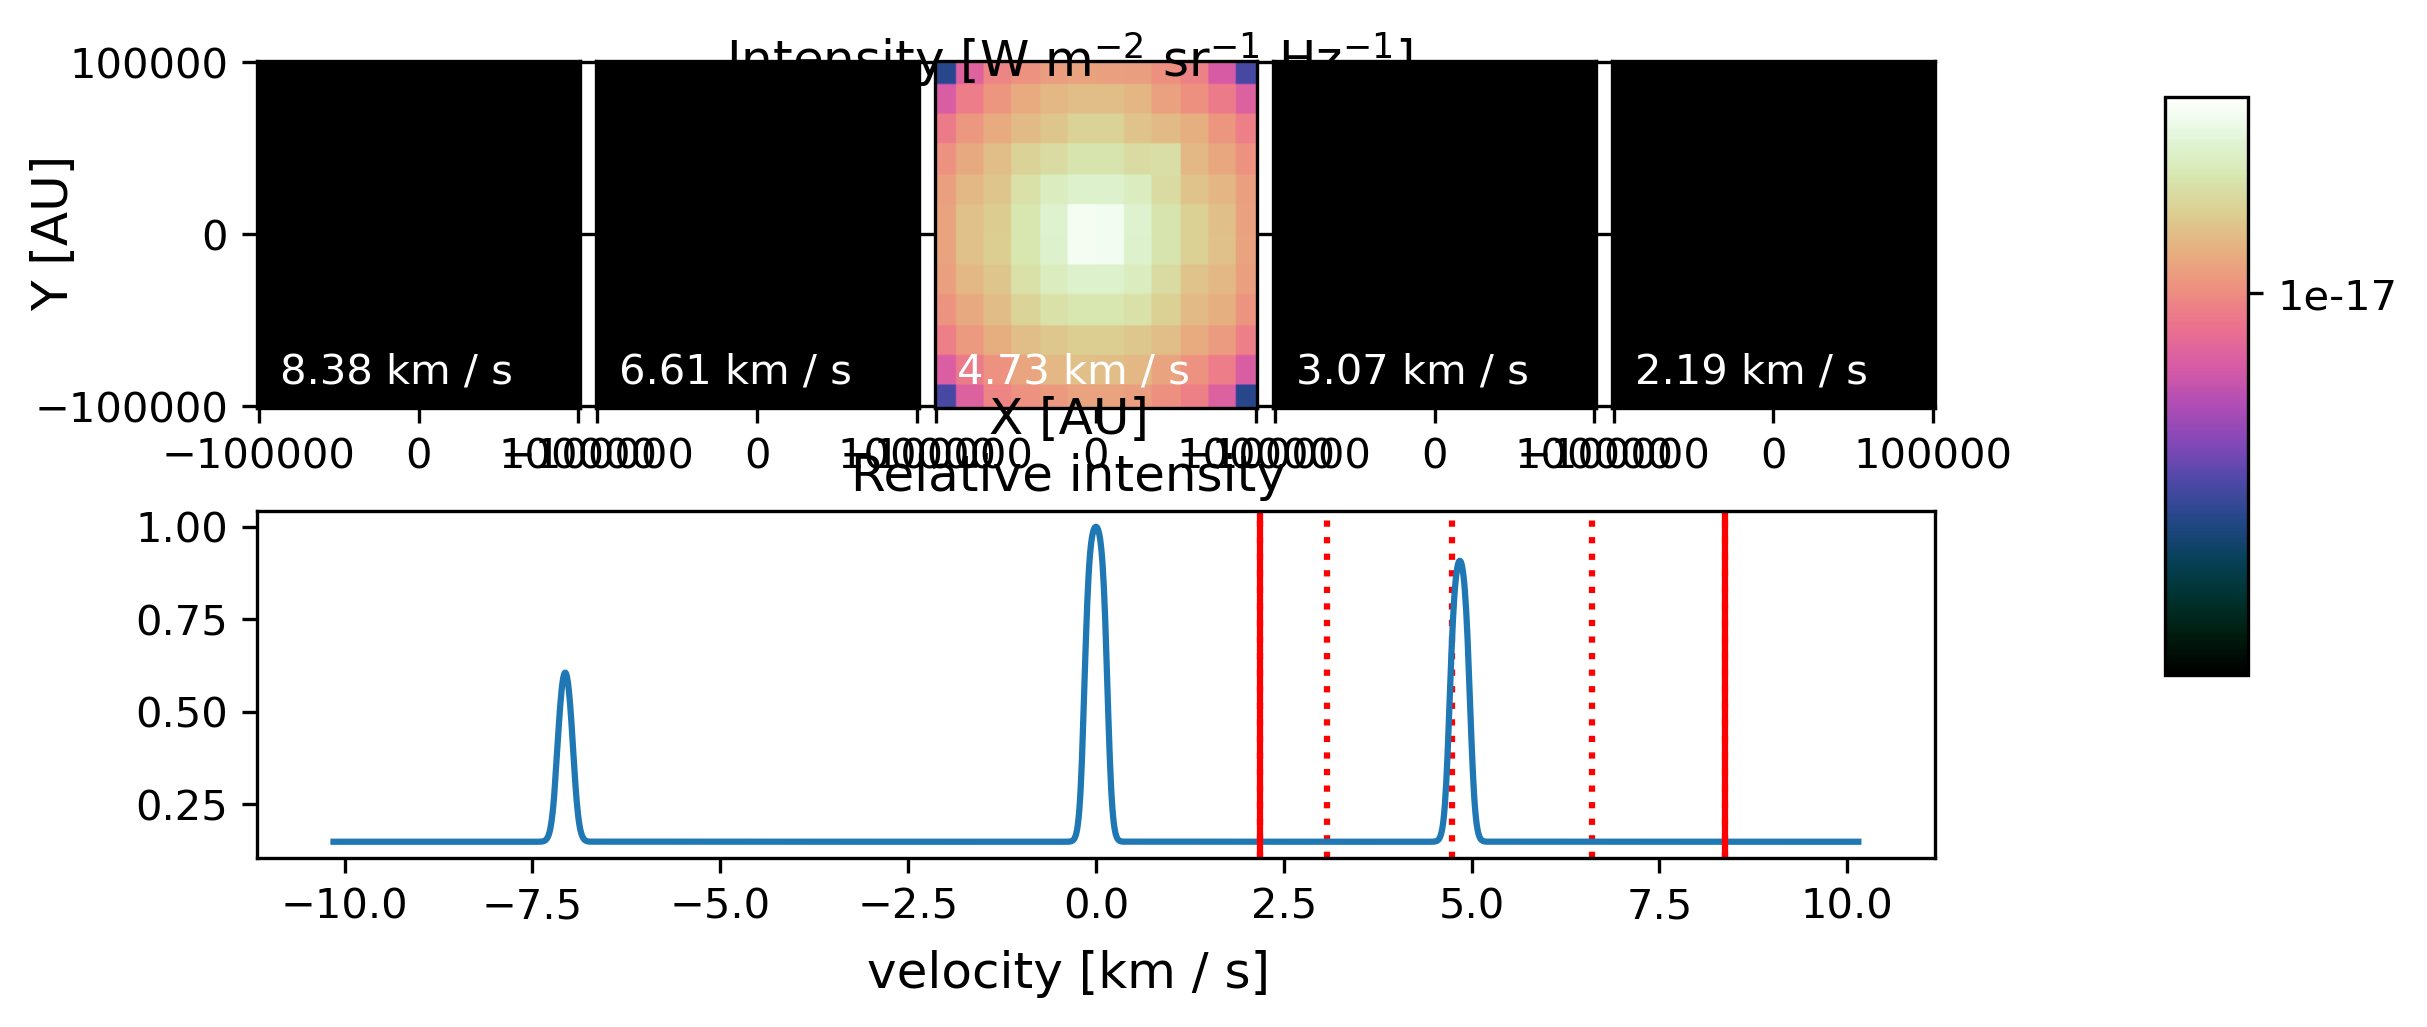

In [9]:
# plot.image_channel(model,[3243,3244],[1,2])
fig,velos,Is=plot.image_channel(model,[200,400,612,800,900],[1,5])
fig

In [ ]:
print(velos,Is)
len(velos), len(Is)
print(max(Is))

NameError: name 'velos' is not defined

In [ ]:
velos1=velos
import matplotlib.pyplot as plt
plt.plot(velos1, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits
hdu = fits.PrimaryHDU(Is/np.max(Is))
print(len(velos1))
hdu.header['CRVAL1'] = velos1[0]
hdu.header['CDELT1'] = velos1[1] - velos1[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos1)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel

fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_oneone_normalised.fits')
hdu.writeto(fits_file, overwrite=True)

hdu = fits.PrimaryHDU(Is)
print(len(velos1))
hdu.header['CRVAL1'] = velos1[0]
hdu.header['CDELT1'] = velos1[1] - velos1[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos1)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel

fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_oneone_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)


NameError: name 'velos' is not defined

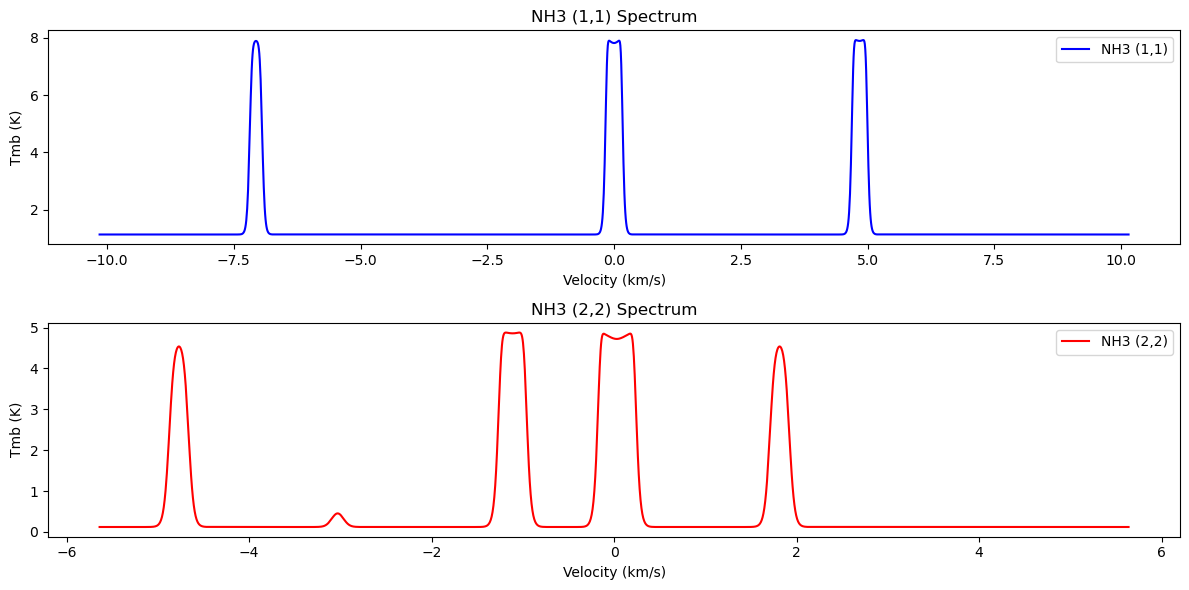

In [ ]:

from astropy import units as u
import astropy.io.fits as fits
import numpy as np

h  = 6.62607015e-34          # Planck  [J s]
k_B  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]

filenames = {'oneone':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_oneone_unnormalised.fits',
    'twotwo':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_twotwo_unnormalised.fits'}

# Load the spectra from the FITS files
spec1 = fits.getdata(filenames['oneone'])
spec2 = fits.getdata(filenames['twotwo'])

# Get velocity axes from FITS headers
with fits.open(filenames['oneone']) as hdul:
    hdr1 = hdul[0].header
    velos1 = hdr1['CRVAL1'] + np.arange(hdr1['NAXIS1']) * hdr1['CDELT1']

with fits.open(filenames['twotwo']) as hdul:
    hdr2 = hdul[0].header
    velos2 = hdr2['CRVAL1'] + np.arange(hdr2['NAXIS1']) * hdr2['CDELT1']

# Get rest frequencies from headers
freq1 = hdr1['RESTFREQ'] 
freq2 = hdr2['RESTFREQ']

# Convert intensity (assumed in W/(m^2 Hz sr)) to main beam temperature (K)
def intensity_to_Tmb(v,I, freq):
    Tmb = (c**2 * I) / (2 * k_B * (freq*(1+v/c))**2)
    return Tmb

Tmb1 = intensity_to_Tmb(1000*velos1,spec1, freq1)
Tmb2 = intensity_to_Tmb(1000*velos2,spec2, freq2)
# now plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(velos1, Tmb1, label='NH3 (1,1)', color='blue')
plt.title('NH3 (1,1) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(velos2, Tmb2, label='NH3 (2,2)', color='red')
plt.title('NH3 (2,2) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.tight_layout()
plt.show()



Computing spectral discretisation...
Computing image new...
length: 67


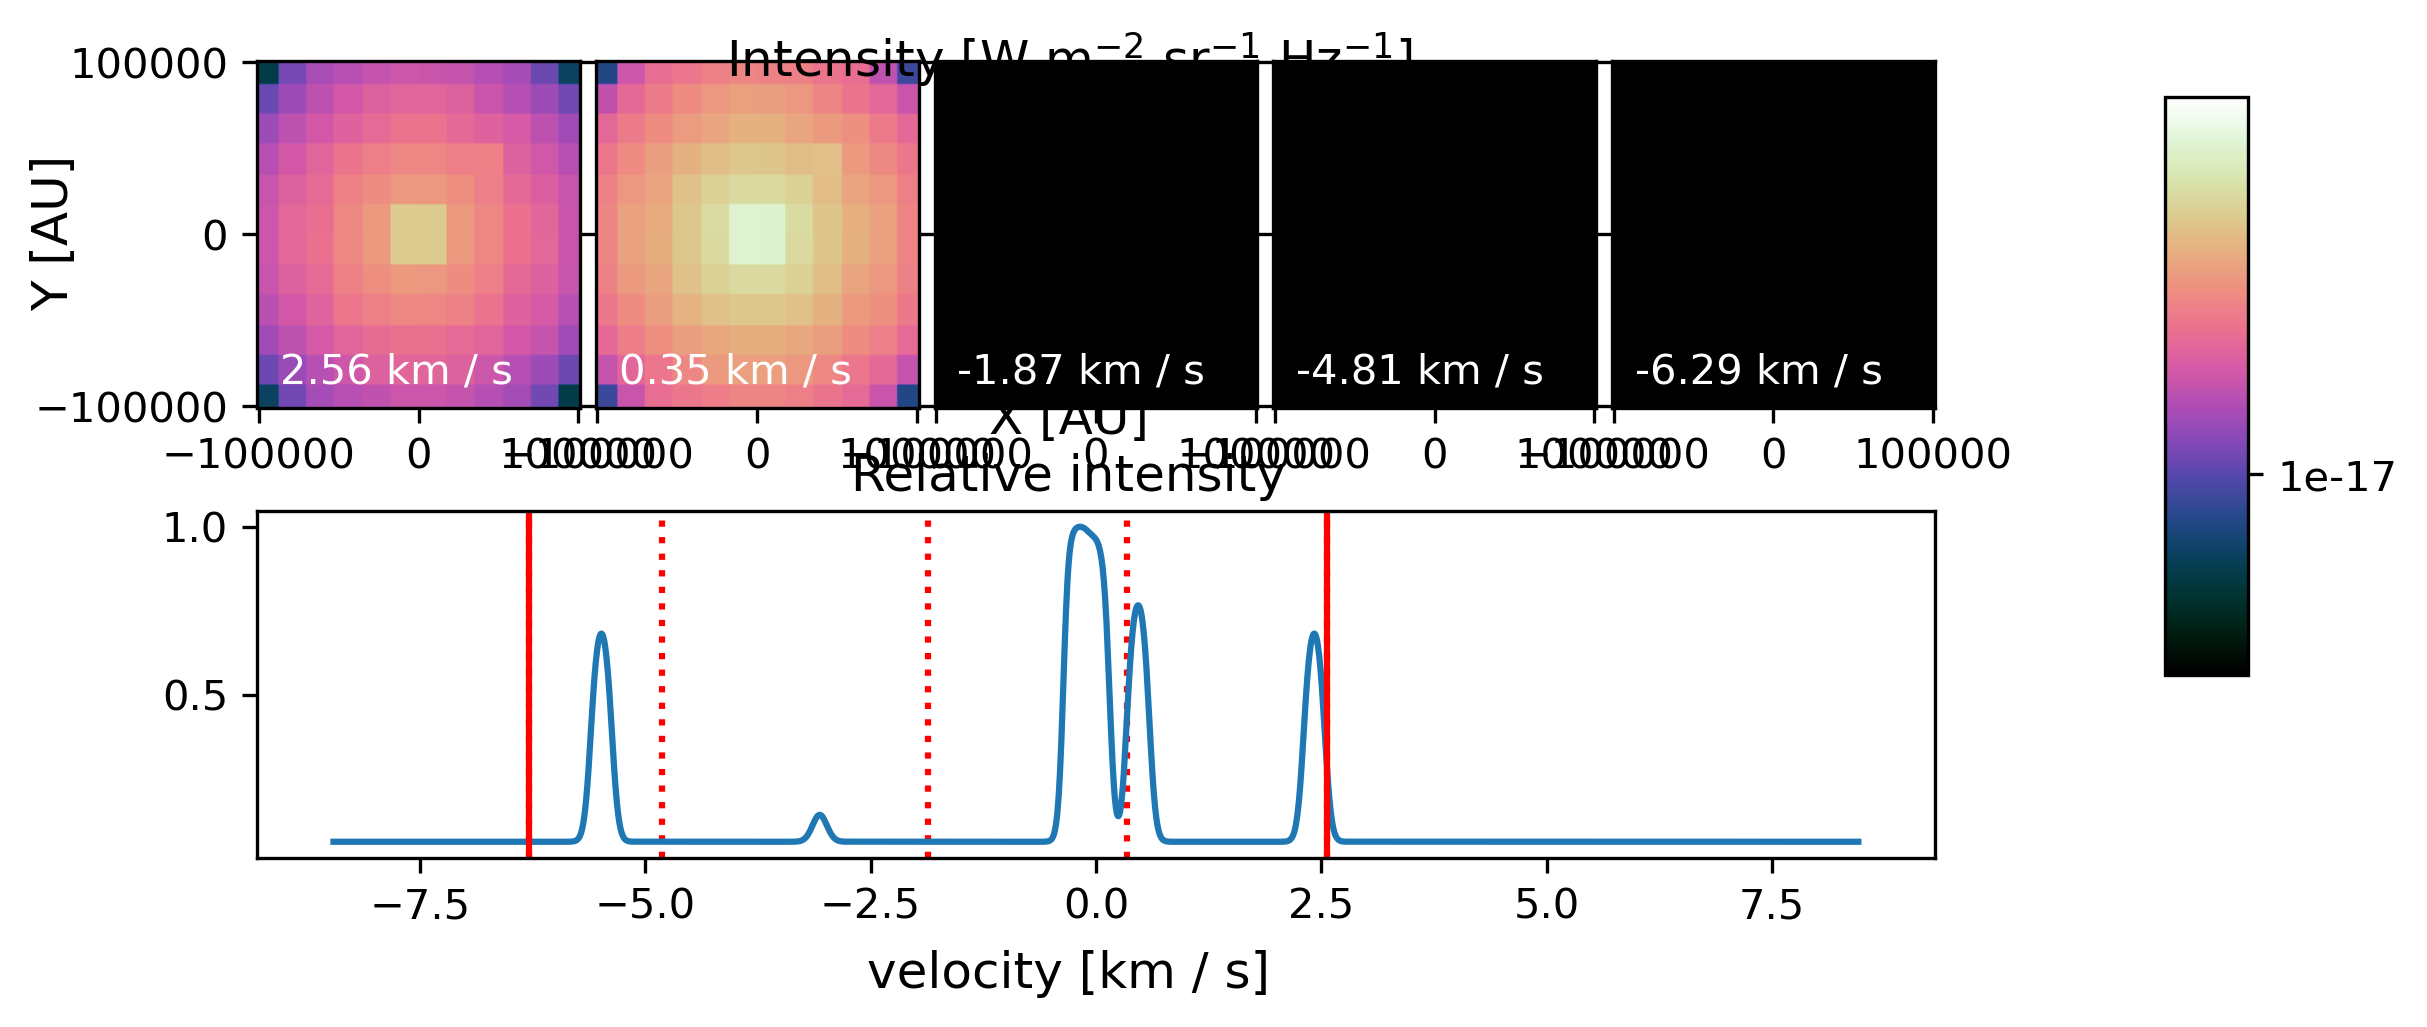

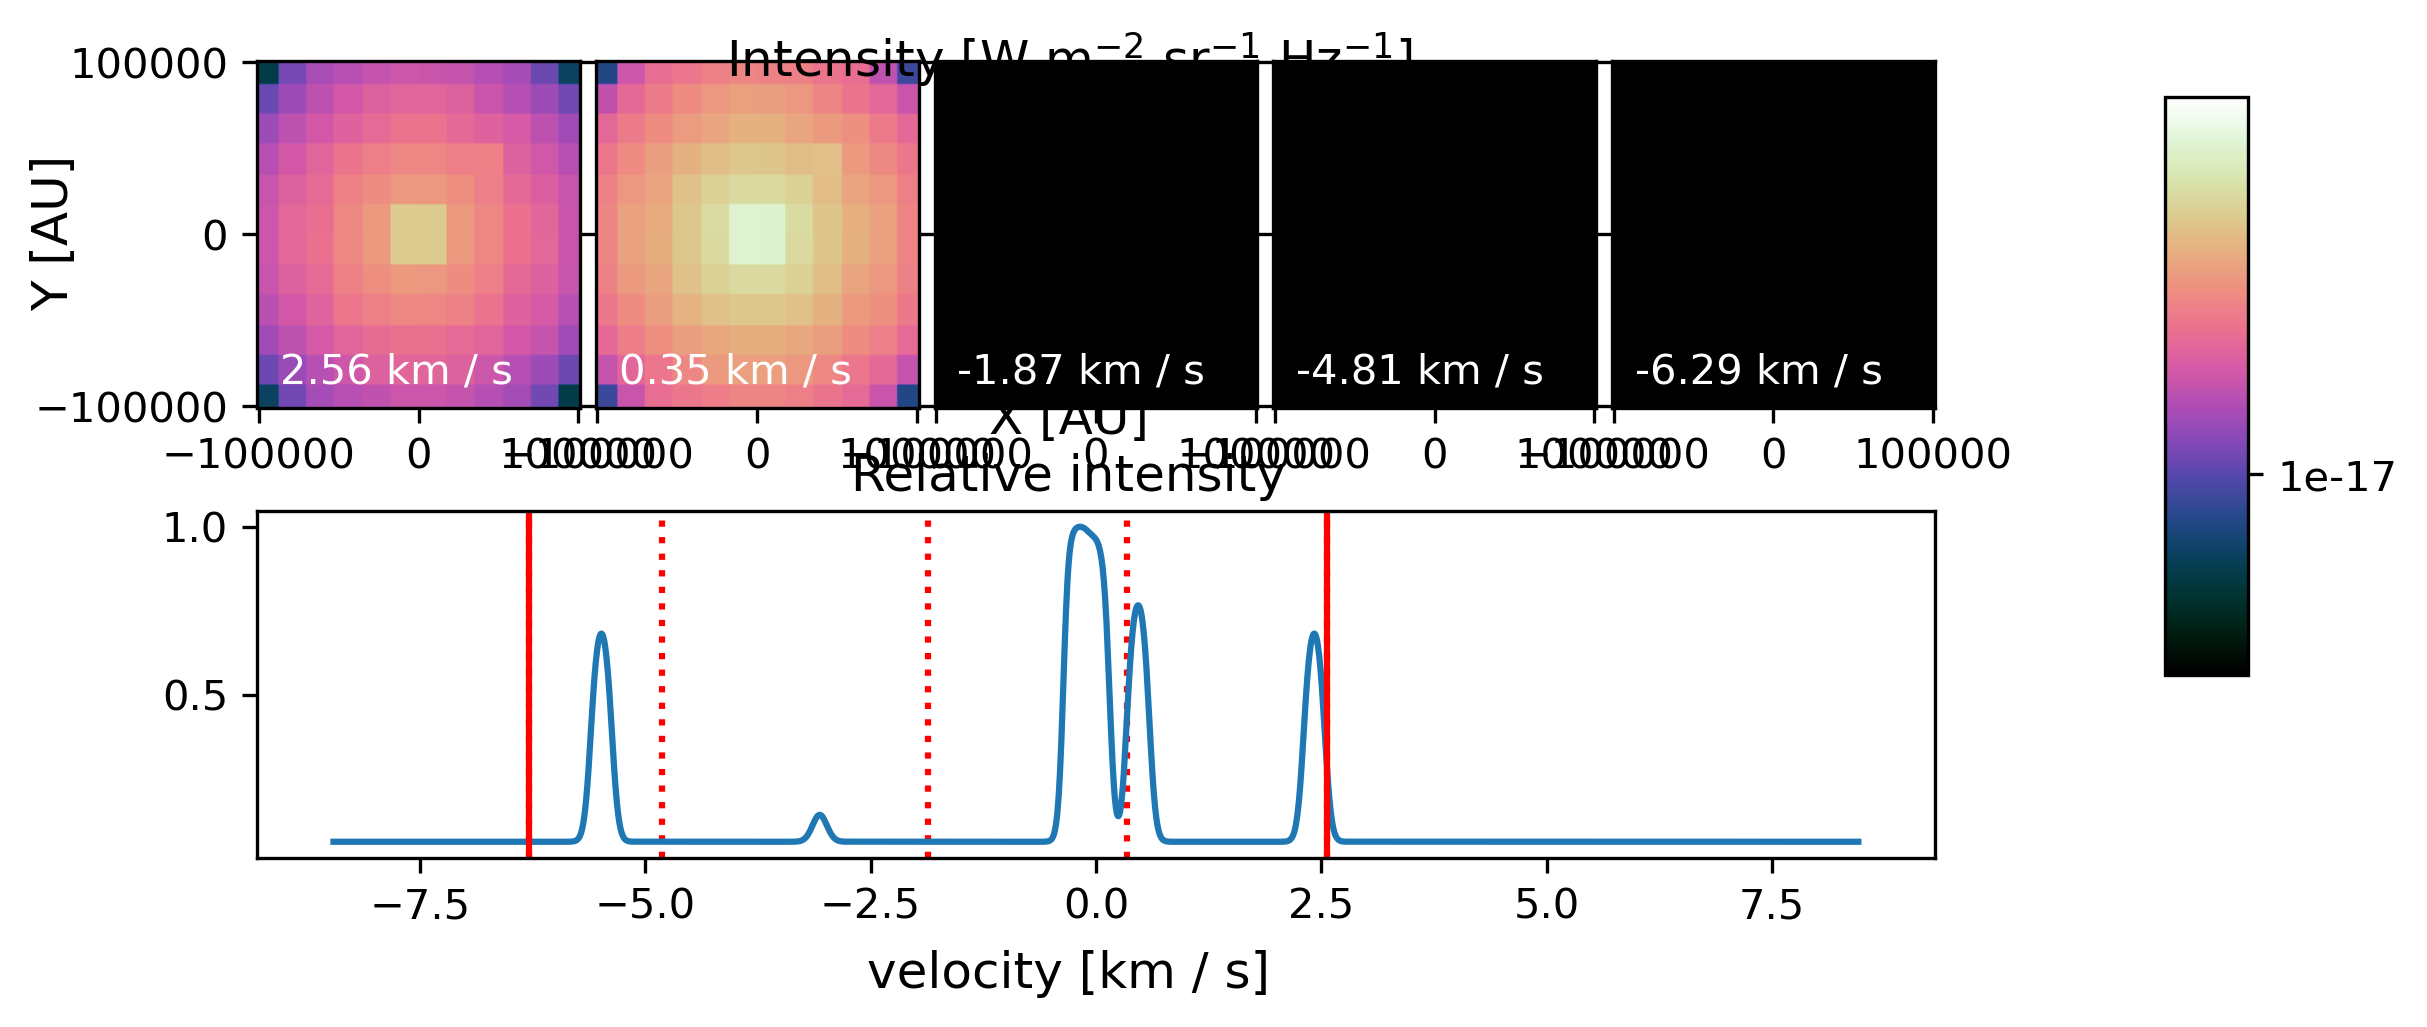

In [ ]:


fcen = model.lines.lineProducingSpecies[0].linedata.frequency[5]
fmin=fcen- 5000000.00
fmax=fcen+ 5000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 

fig,velos,Is=plot.image_channel(model,[800,1100,1400,1800,2000],[1,5])
fig

[ 8.45629632  8.44892378  8.44155125 ... -8.44155125 -8.44892378
 -8.45629632]


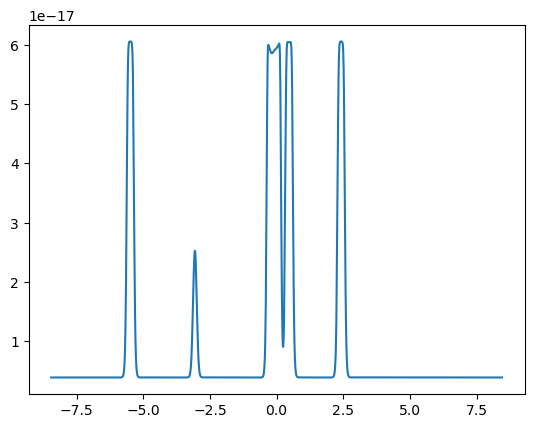

In [ ]:
velos2=velos
print(velos2)
#shift velo to have the centre at 0
plt.plot(velos2, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits
hdu = fits.PrimaryHDU(Is/np.max(Is))

hdu.header['CRVAL1'] = velos2[0]
hdu.header['CDELT1'] = velos2[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_normalised.fits')
hdu.writeto(fits_file, overwrite=True)

hdu = fits.PrimaryHDU(Is)

hdu.header['CRVAL1'] = velos2[0]
hdu.header['CDELT1'] = velos2[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)


Computing spectral discretisation...
Computing image new...
length: 67


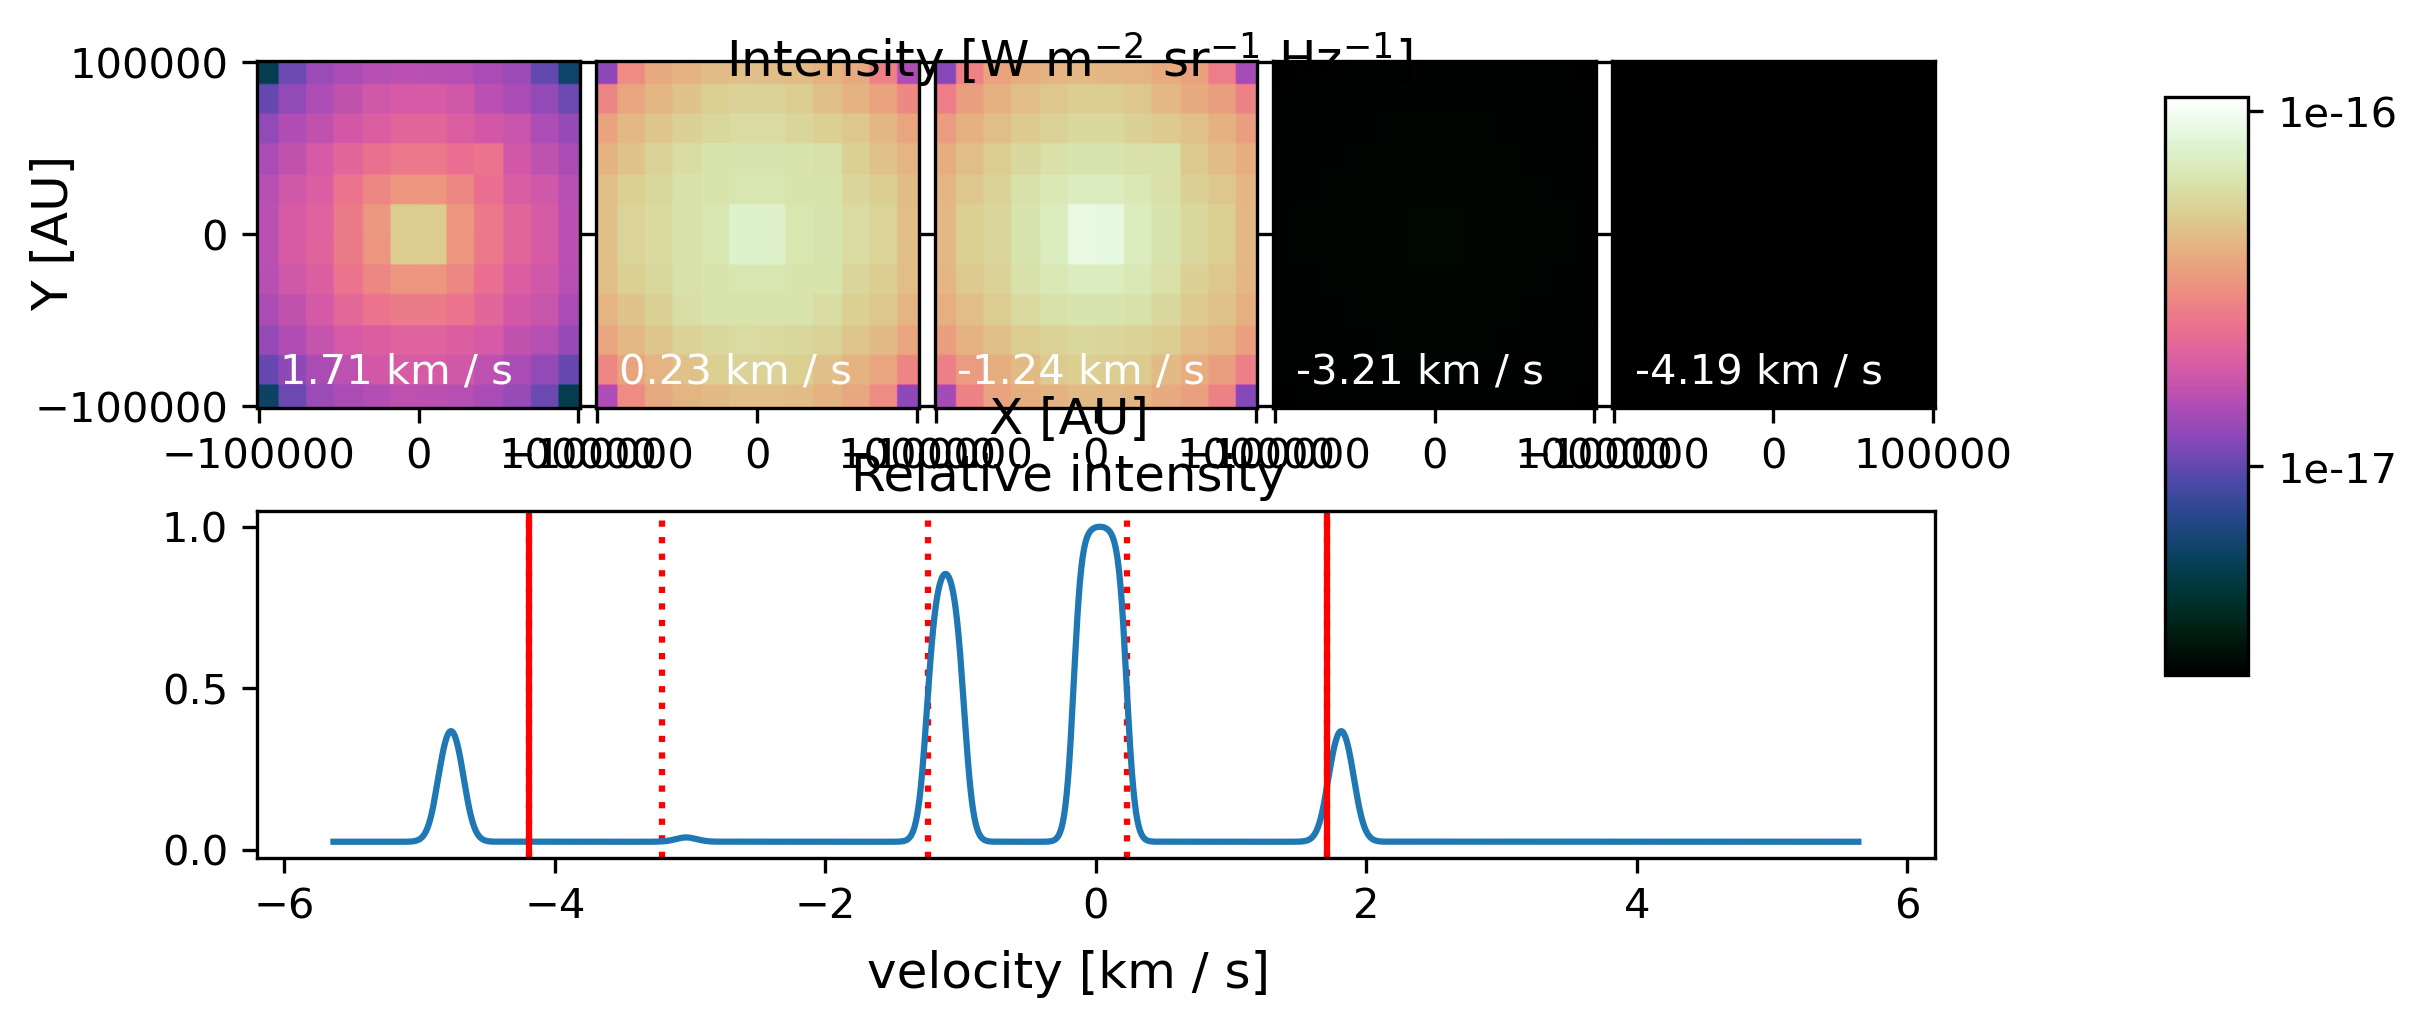

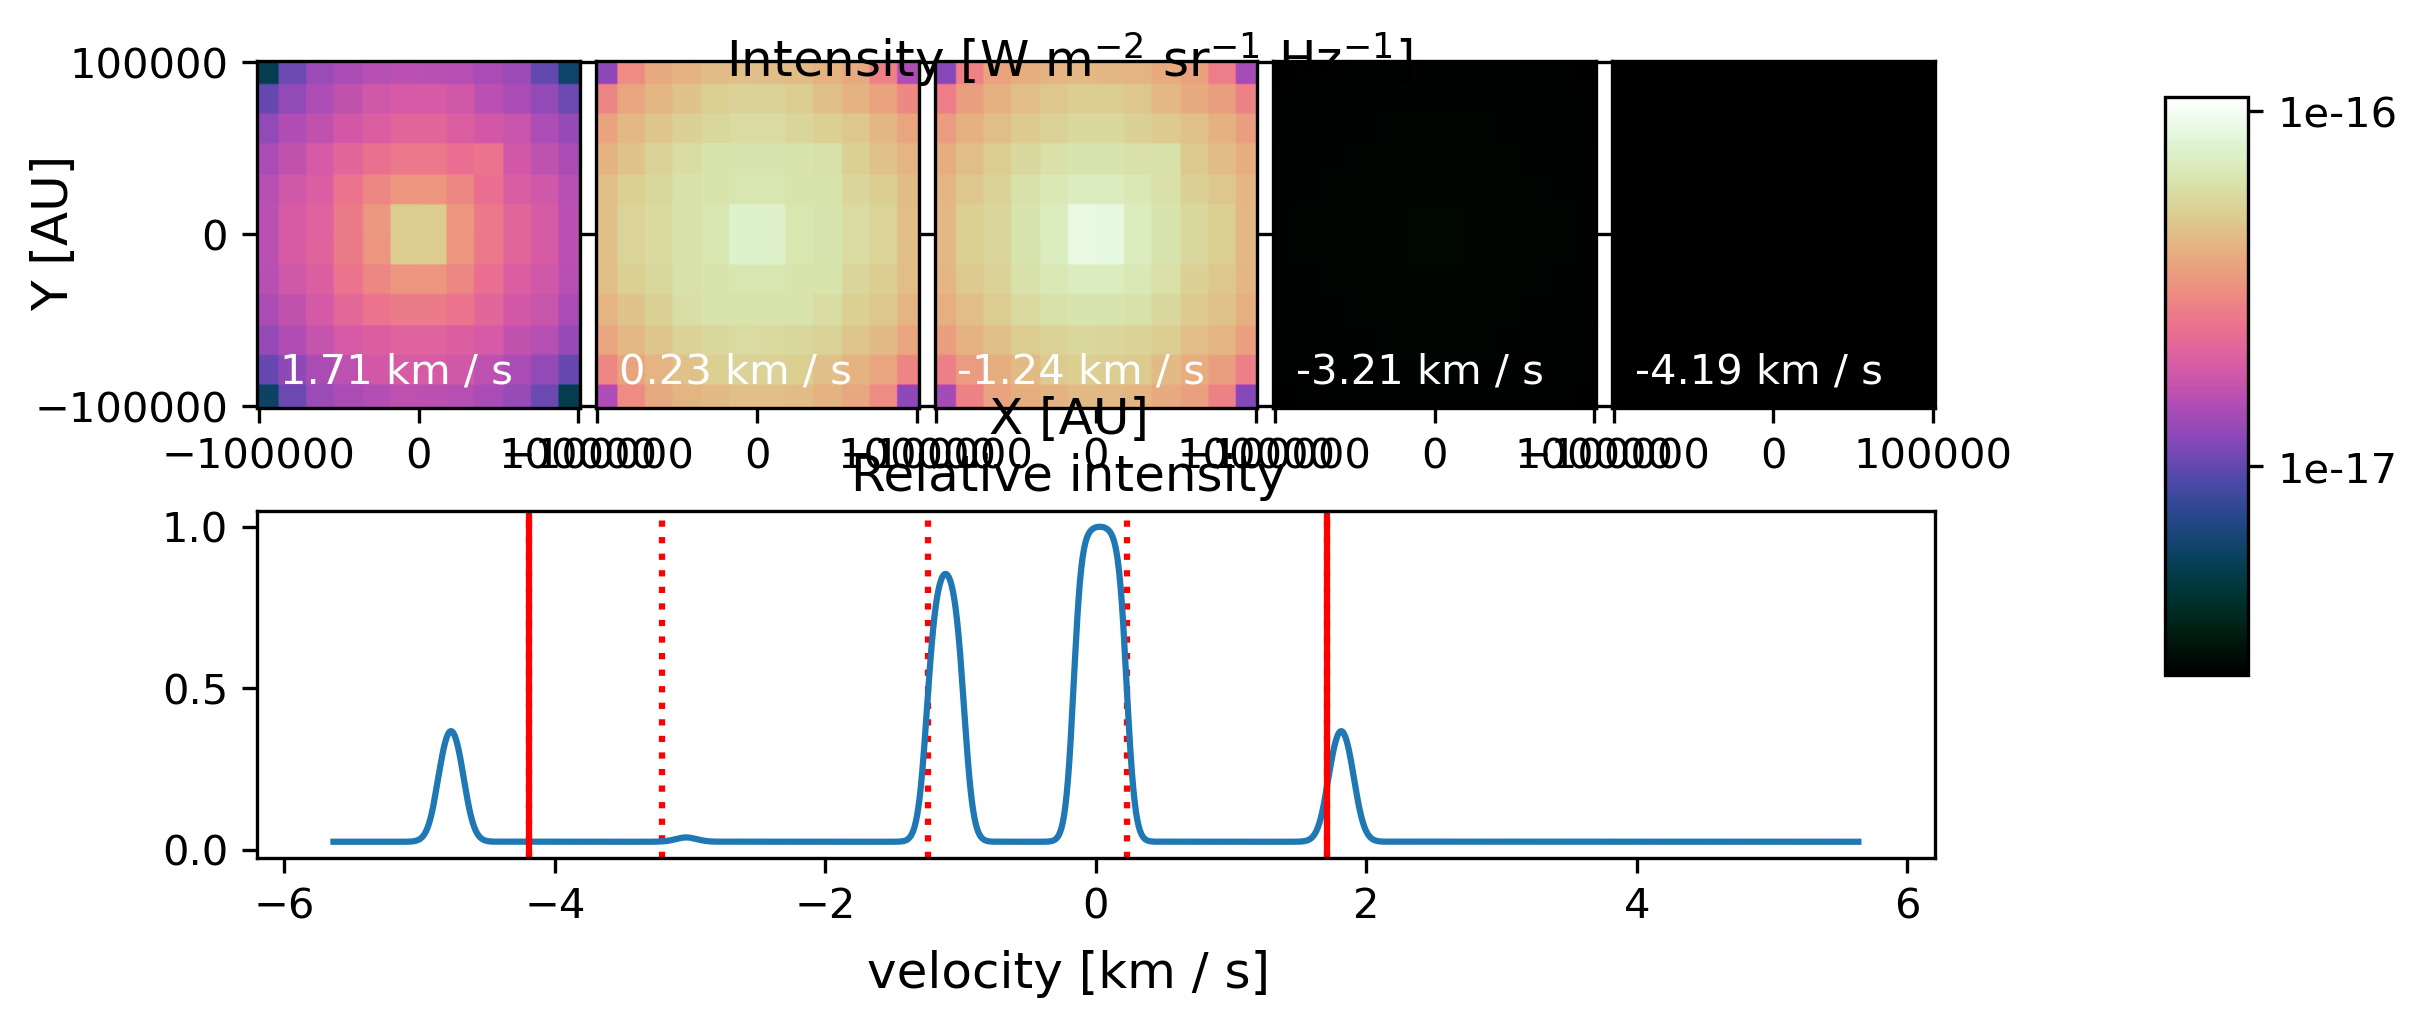

In [ ]:
fcen = model.lines.lineProducingSpecies[0].linedata.frequency[12]
fmin=fcen- 5000000.00
fmax=fcen+ 5000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 

fig=plot.image_channel(model,[800,1100,1400,1800,2000],[1,5])
fig

[ 8.45629632  8.44892378  8.44155125 ... -8.44155125 -8.44892378
 -8.45629632]


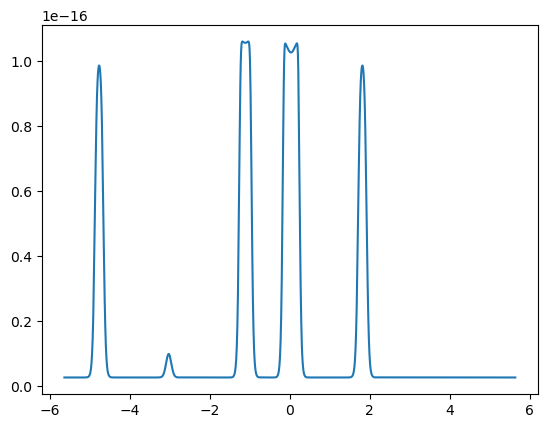

In [ ]:
velos3=velos
print(velos2)
#shift velo to have the centre at 0
plt.plot(velos3, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits
hdu = fits.PrimaryHDU(Is/np.max(Is))

hdu.header['CRVAL1'] = velos3[0]
hdu.header['CDELT1'] = velos3[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos3)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_normalised.fits')
hdu.writeto(fits_file, overwrite=True)

hdu = fits.PrimaryHDU(Is)

hdu.header['CRVAL1'] = velos3[0]
hdu.header['CDELT1'] = velos3[1] - velos3[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)

In [ ]:
# plot.image_mpl(
#     model,
#     image_nr =  -1,
#     zoom     = 1.3,
#     npix_x   = 16,
#     npix_y   = 16,
#     x_unit   = units.au,
#     v_unit   = units.km / units.s)

(The plot is only interactive in a live notebook.)

Save the image cube in a fits file.

In [ ]:
# tools.save_fits(model)

(Optional: To create your own plots) Overview of data stored in the Image object

In [ ]:
# import numpy as np
# xdir = np.array(model.images[-1].image_direction_x)#directions of the x-and y-vectors of the image
# ydir = np.array(model.images[-1].image_direction_y)
# zdir = np.array(model.images[-1].image_direction_z)#this is direction in which we observe the object
# print("image directions: ", xdir, ydir, zdir)
# nfreqs = np.array(model.images[-1].nfreqs) #number of frequency bins
# freqs = np.array(model.images[-1].freqs) #frequency bins [Hz]
# print("# of frequencies: ", nfreqs, " frequencies :", freqs)
# ImX = np.array(model.images[-1].ImX)#X position in image [m]
# ImY = np.array(model.images[-1].ImY)#Y position in image [m]
# I = np.array(model.images[-1].I)#Intensity at the corresponding ImX, ImY position [W/(m^2*Hz*sr)], at a given frequency bin
# # print("Intensities :", I, " ImX:", ImX, "ImY:", ImY) #prints a lot of output

INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,2295 [pyspeckit.spectrum.interactive]
RMS guess (errspec):  1.0
RMS guess (residuals):  0.21455275160850956
INFO: Creating spectra [pyspeckit.spectrum.classes]
INFO: Concatenating data [pyspeckit.spectrum.classes]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,4590 [pyspeckit.spectrum.interactive]
Iter       1    CHI-SQUARE =  5122.502955  DOF =  4584
   trot0 = 5.65  
   tex0 = 4.49  
   ntot0 = 15.5  
   width0 = 84.29155401  
   xoff_v0 = -3213.997078  
   fortho0 = 0.3  
Iter       2    CHI-SQUARE =  4966.323762  DOF =  4584
   trot0 = 6.192029909  
   tex0 = 4.477665628  
   ntot0 = 15.93649792  
   width0 = 84.26639696  
   xoff_v0 = -3213.994764  
   fortho0 = 1  
Iter       3    CHI-SQUARE =  4966.323754  DOF =  4584
   trot0 = 5.192029909  
   tex0 = 4.477660645  
   ntot0 = 15.93649695  
   width0 = 84.26640865  
   xoff_v0 = -3213.994704  
   fortho0 = 1  


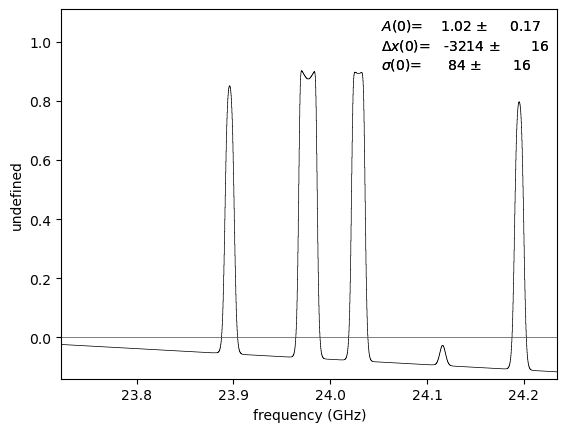

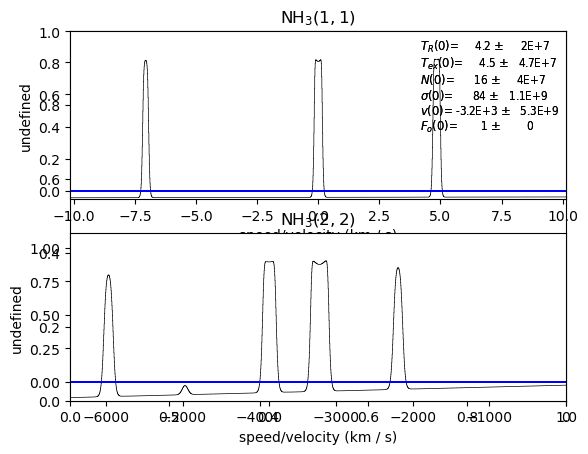

In [ ]:
import pyspeckit

# The ammonia fitting wrapper requires a dictionary specifying the transition name
# (one of the four specified below) and the filename.  Alternately, you can have the
# dictionary values be pre-loaded Spectrum instances
filenames = {'oneone':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_oneone_normalised.fits',
    'twotwo':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_twotwo_normalised.fits'}

# Fit the ammonia spectrum with some reasonable initial guesses.  It is
# important to crop out extraneous junk and to smooth the data to make the
# fit proceed at a reasonable pace.
spdict1,spectra1 = pyspeckit.wrappers.fitnh3.fitnh3tkin(filenames,crop=False,npeaks=1,guessline='twotwo',rebase=True,tkin=5.65,tex=4.49,column=15.5,fortho=0.3,verbose=True, smooth=False,dobaseline=True,doplot=True,fittype='ammonia')


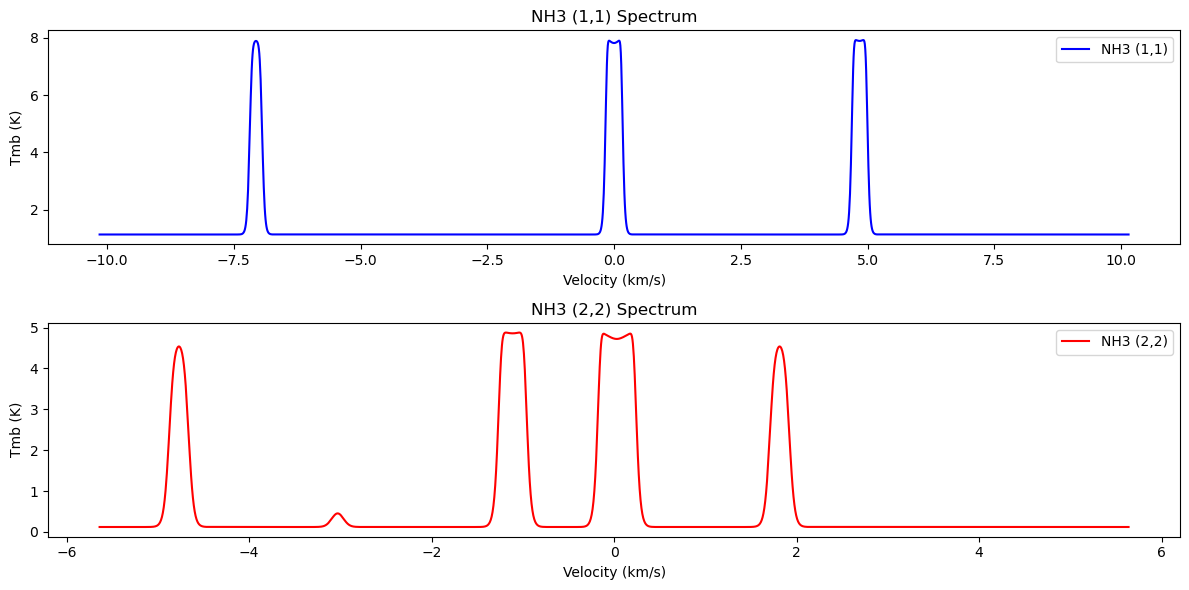

In [ ]:

from astropy import units as u
import astropy.io.fits as fits
import numpy as np

h  = 6.62607015e-34          # Planck  [J s]
k_B  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]

filenames = {'oneone':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_oneone_unnormalised.fits',
    'twotwo':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_twotwo_unnormalised.fits'}

# Load the spectra from the FITS files
spec1 = fits.getdata(filenames['oneone'])
spec2 = fits.getdata(filenames['twotwo'])

# Get velocity axes from FITS headers
with fits.open(filenames['oneone']) as hdul:
    hdr1 = hdul[0].header
    velos1 = hdr1['CRVAL1'] + np.arange(hdr1['NAXIS1']) * hdr1['CDELT1']

with fits.open(filenames['twotwo']) as hdul:
    hdr2 = hdul[0].header
    velos2 = hdr2['CRVAL1'] + np.arange(hdr2['NAXIS1']) * hdr2['CDELT1']

# Get rest frequencies from headers
freq1 = hdr1['RESTFREQ'] 
freq2 = hdr2['RESTFREQ']

# Convert intensity (assumed in W/(m^2 Hz sr)) to main beam temperature (K)
def intensity_to_Tmb(v,I, freq):
    Tmb = (c**2 * I) / (2 * k_B * (freq*(1+v/c))**2)
    return Tmb

Tmb1 = intensity_to_Tmb(1000*velos1,spec1, freq1)
Tmb2 = intensity_to_Tmb(1000*velos2,spec2, freq2)
# now plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(velos1, Tmb1, label='NH3 (1,1)', color='blue')
plt.title('NH3 (1,1) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(velos2, Tmb2, label='NH3 (2,2)', color='red')
plt.title('NH3 (2,2) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.tight_layout()
plt.show()



[ 1.13052731e+00 -3.48545274e-02  7.79390918e+00  2.03034442e-04
  1.29509718e-01  1.24754913e-01  3.11431424e+00  9.22559911e-01
  7.89624331e+00  4.84334664e+00  1.20376396e-01  1.40621534e-01
  6.28015676e+00  6.67338735e-01  3.39784462e-01  9.44339306e+00
  2.00461882e+00]
[ 1.19279219e-01  1.28129748e-03  4.70586142e+00 -4.76868505e+00
  8.47033802e-02  3.35108192e-01 -3.02929948e+00  6.62441565e-02
  5.47338194e+00 -1.11189857e+00  1.19596117e-01  5.43938648e+00
  3.26530353e-02  1.60103511e-01  4.69882182e+00  1.81382093e+00
  8.45114518e-02]


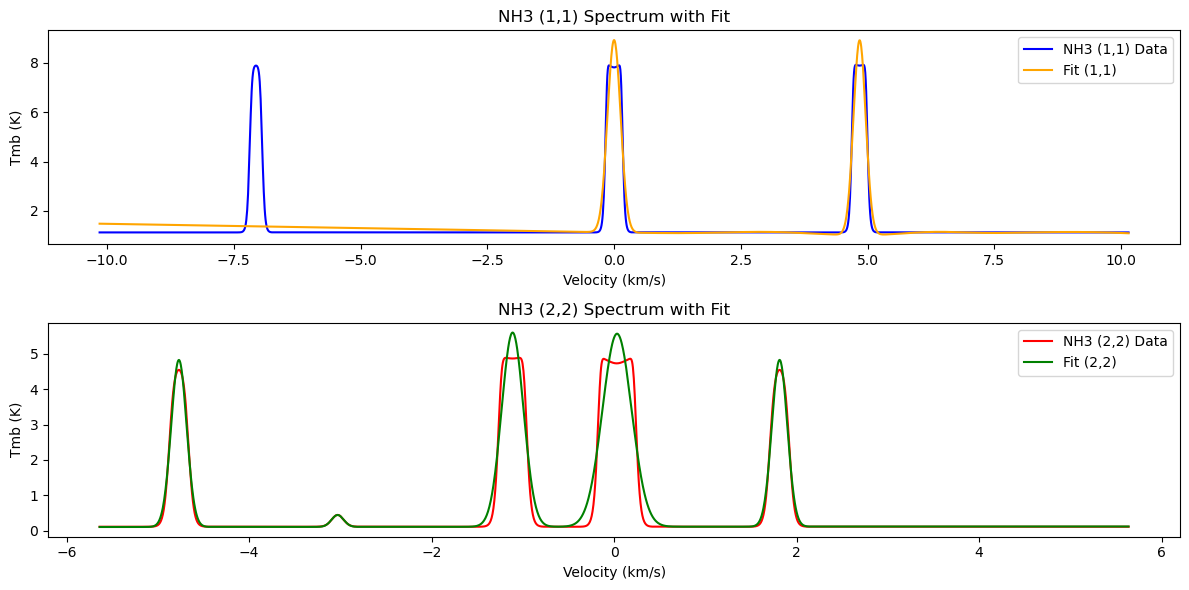

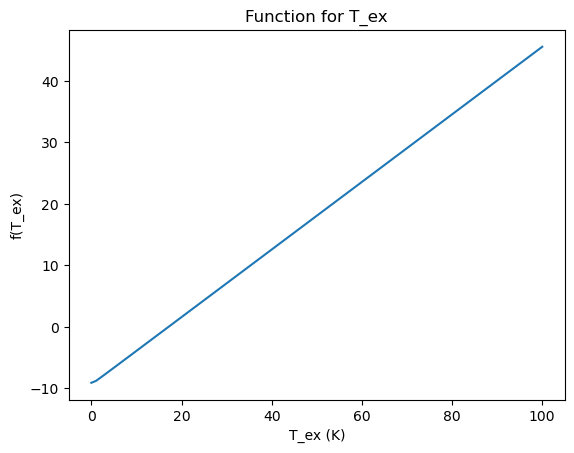

∫Tmb dv (1,1): 7.144 K km/s
∫Tmb dv (2,2): 5.874 K km/s
τ(1,1)       : 0.80
T_ex (1,1)   : 17.12 K
T_rot        : 54.01 K
T_kin        : 233.52 K


In [ ]:

"""
NH3 (1,1) and (2,2) line analysis: Gaussian fitting, τ, T_ex, T_rot
"""
import numpy as np
from scipy.optimize import curve_fit, brentq

# --------------------------- constants ---------------------------
h  = 6.62607015e-34          # Planck  [J s]
k  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]
T_BG  = 2.73                 # CMB [K]
NU_11 = 23.6944955e9         # NH3 (1,1) [Hz]
NU_22 = 23.7226333e9         # NH3 (2,2) [Hz]
DELTA_E_K = 42.32            # (2,2)–(1,1) energy gap [K]

# --------------------------- models ---------------------------
def gaussian(v, amp, cen, sig):
    """Single Gaussian."""
    return amp * np.exp(-0.5 * ((v - cen)/sig)**2)

def multi_gaussian(v,*pars):
    """Sum of N Gaussians; pars = [amp1,cen1,sig1, …, ampN,cenN,sigN]."""
    n = len(pars)//3
    out = np.zeros_like(v)
    for i in range(n):
        a, c, s = pars[2+3*i :2+3*i+3]
        out += gaussian(v, a, c, s)
    return out + pars[0] + pars[1] * v  # offset + slope

# --------------------------- fitting ---------------------------
def fit_five_gaussians(v, tmb, number, p0=None):
    """Fit 5 Gaussians; returns best-fit parameters (len=15) with positive amplitudes."""
    if p0 is None:  # crude automatic seed
        idx_max = np.argmax(tmb)
        vpk, amp_pk = v[idx_max], tmb[idx_max]
        width = (v[0] - v[-1]) / 40
        if number == 'one':
            centres = np.linspace(vpk-10*width, vpk+10*width, 5)
        else:
            centres = np.linspace(vpk-12.5*width, vpk+12.5*width, 5)
        p0 = [(tmb[0]+tmb[-1])/2, (tmb[-1]-tmb[0])/(v[-1]-v[0])]  # guess for offset and slope
        for c in centres:
            p0 += [max(amp_pk/3, 1e-3), c, width]  # ensure positive initial amplitude
            # Set bounds: offset free, amplitudes >=0, widths > 0, centers free
            lower_bounds = [min(tmb), -np.inf]
            for i in range(15):
                if i % 3 == 0:      # amplitude
                    lower_bounds.append(0.001)
                elif i % 3 == 2:    # width (sigma)
                    lower_bounds.append(1e-6)
                else:               # center
                    lower_bounds.append(-np.inf)

            upper_bounds = [max(tmb)] + [np.inf] * 16

    pars, _ = curve_fit(
        lambda vv, *pp: multi_gaussian(vv, *pp),
        v, tmb, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=200000
    )
    return pars

def comp_areas(pars):
    """Return arrays of areas (K km/s) for each Gaussian component."""
    amps  = pars[2::3]
    sigs  = pars[4::3]
    return amps * sigs * np.sqrt(2*np.pi)

# ------------------------ line diagnostics -----------------------
def J_nu(T, nu):
    return (h*nu/k) / (np.exp(h*nu/(k*T)) - 1)

def tau_from_sat(Ts, Tm, a_s=0.22):
    """Solve τ from T_s/T_m ratio (inner satellite)."""
    f = lambda tau: (1 - np.exp(-a_s*tau))/(1 - np.exp(-tau)) - Ts/Tm
    return brentq(f, 1e-4, 100)

def tex_from_tau(Tmb_peak, tau, nu, method= 'brentq'):
    if method == 'brentq':
        """Solve T_ex from radiative-transfer equation."""
        Jbg = J_nu(T_BG, nu)
        f = lambda Tex: (J_nu(Tex, nu) - Jbg)*(1 - np.exp(-tau)) - Tmb_peak
        #plot f at a range of values
        import matplotlib.pyplot as plt
        Tex_vals = np.linspace(0, 100, 100)
        plt.plot(Tex_vals, f(Tex_vals), label='f(Tex)')
        plt.xlabel('T_ex (K)')
        plt.ylabel('f(T_ex)')
        plt.title('Function for T_ex')
        plt.show()
        return brentq(f, 1e-4, 100)
    elif method == 'simple':
        return Tmb_peak/(1-np.exp(-tau)) + T_BG

def T_rot(int11, int22):
    ratio = (int11/int22) * (9/5)          # statistical weight factor
    return DELTA_E_K / np.log(ratio)

# ------------------------------- main ---------------------------
def analyse_pair(v11, t11, v22, t22,
                 main_idx11=2, sat_idx11=1, a_s=0.22):
    # ----- fit spectra
    p11 = fit_five_gaussians(v11, t11,'one')
    p22 = fit_five_gaussians(v22, t22,'two')
    print(p11)
    print(p22)
    #plot the fitted spectra
    amps11  = p11[2::3]; cents11=p11[3::3];  sigs11 = p11[4::3]*1000
    amps22  = p22[2::3]; cents22=p22[3::3];  sigs22 = p22[4::3]*1000

    #plot the fitted spectra
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(v11, t11, label='NH3 (1,1) Data', color='blue')
    plt.plot(v11, multi_gaussian(v11, *p11), label='Fit (1,1)', color='orange')
    plt.title('NH3 (1,1) Spectrum with Fit')
    plt.xlabel('Velocity (km/s)')
    plt.ylabel('Tmb (K)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(v22, t22, label='NH3 (2,2) Data', color='red')
    plt.plot(v22, multi_gaussian(v22, *p22), label='Fit (2,2)', color='green')
    plt.title('NH3 (2,2) Spectrum with Fit')
    plt.xlabel('Velocity (km/s)')
    plt.ylabel('Tmb (K)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- integrated intensities (K km/s)
    I11 = np.sum(comp_areas(p11))
    I22 = np.sum(comp_areas(p22))

    # ----- optical depth via satellite ratio
    tau_11 = tau_from_sat(amps11[sat_idx11], amps11[main_idx11], a_s)

    # ----- excitation temperature
    Tex_11 = tex_from_tau(amps11[main_idx11], tau_11, NU_11, method='brentq')

    # ----- rotational temperature
    Trot = T_rot(I11, I22)

    # ----- kinetic temperature
    Tkin = Trot /(1-(Trot/42)*np.log(1+1.1*np.exp(-16/Trot)))

    return dict(I11=I11, I22=I22, tau_11=tau_11, Tex_11=Tex_11,
                Trot=Trot, Tkin=Tkin, fit_params_11=p11, fit_params_22=p22)

res = analyse_pair(velos1, Tmb1, velos2, Tmb2,
                       main_idx11=2,
                       sat_idx11=4,
                       a_s=0.03)

print(f"∫Tmb dv (1,1): {res['I11']:.3f} K km/s")
print(f"∫Tmb dv (2,2): {res['I22']:.3f} K km/s")
print(f"τ(1,1)       : {res['tau_11']:.2f}")
print(f"T_ex (1,1)   : {res['Tex_11']:.2f} K")
print(f"T_rot        : {res['Trot']:.2f} K")
print(f"T_kin        : {res['Tkin']:.2f} K")


In [ ]:
import numpy as np
xdir = np.array(model.images[-1].image_direction_x)#directions of the x-and y-vectors of the image
ydir = np.array(model.images[-1].image_direction_y)
zdir = np.array(model.images[-1].image_direction_z)#this is direction in which we observe the object
print("image directions: ", xdir, ydir, zdir)
nfreqs = np.array(model.images[-1].nfreqs) #number of frequency bins
freqs = np.array(model.images[-1].freqs) #frequency bins [Hz]
print("# of frequencies: ", nfreqs, " frequencies :", freqs)
ImX = np.array(model.images[-1].ImX)#X position in image [m]
ImY = np.array(model.images[-1].ImY)#Y position in image [m]
I = np.array(model.images[-1].I)#Intensity at the corresponding ImX, ImY position [W/(m^2*Hz*sr)], at a given frequency bin
# print("Intensities :", I, " ImX:", ImX, "ImY:", ImY) #prints a lot of output

image directions:  [ 0. -1.  0.] [ 0.  0. -1.] [1. 0. 0.]
# of frequencies:  2295  frequencies : [2.65881562e+11 2.65881567e+11 2.65881571e+11 ... 2.65891554e+11
 2.65891558e+11 2.65891562e+11]
